In [1]:
!pip install -U 'skorch[pytorch]' && pip install -q -U faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 38.1 MB/s eta 0:00:00


In [2]:
import os
import torch
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm
from time import time, sleep
import itertools

import sklearn
from sklearn.frozen import FrozenEstimator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split

from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import (
                StandardScaler, KBinsDiscretizer, TargetEncoder,
                OneHotEncoder, LabelEncoder, label_binarize
)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [4]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(seed=CFG['SEED'])

## Load Data

In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

## Preprocess Features

In [7]:
## -- Helper functions --
def get_class_weights(y):
    """
    y: Current y_labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y_labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG["SEED"]).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te.astype('float32')
    X_va_1[te_names] = X_va_te.astype('float32')
    X_ts_1[te_names] = X_ts_te.astype('float32')

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print("- Helper functions ready -")

- Helper functions ready -


In [8]:
# -- FE by @yekenot

X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
y = train[TARGET]
X_test = test.drop(columns=[ID]); test_id = test[ID]

del train, test
print("X      init shape:", X.shape)
print("X_ts init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('heart_rate', 'bmi'),
]
important_combos = sorted(important_combos)
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)
    
    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Categorize numericals
    for col in num_cols:
        cat_name = f"{col}_cat_"

        if col == 'calorie_expenditure':
            df[cat_name] = (df[col] // 5).astype('int32').astype('category')
            continue

        if col == 'water_intake':
            df['water_intake_cat2_'] = (df[col] * 50).astype('int32').astype('category')

        round_level = -1
        if fit:
            round_flag = col == 'step_count'
            series = df[col].round(round_level) if round_flag else df[col]
            codes, uniques = series.factorize()
            category_map[col] = {'uniques': uniques, 'round_flag': round_flag}
        else:
            round_flag = category_map[col]['round_flag']
            uniques = category_map[col]['uniques']
            series = df[col].round(round_level) if round_flag else df[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = series.map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes    
        df[cat_name] = df[cat_name].astype('category')

    # Discretize numericals
    bin_config = {'sleep_duration': [70], 'water_intake': [10]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')    

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols

X, new_cat_cols, new_num_cols = feature_engineering(X, fit=True)
X_test, new_cat_cols, new_num_cols = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_test = X_test.reindex(sorted(X_test.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (690088, 13)
X_ts init shape: (295753, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 11
len(new_num_cols): 0 

prep len(cat_cols): 17
prep len(num_cols): 7 

X      prep shape: (690088, 24)
X_test prep shape: (295753, 24) 



In [9]:
X.head()

,bmi,bmi_cat_,calorie_expenditure,calorie_expenditure_cat_,diet_type,exercise_duration,exercise_duration_cat_,gender,heart_rate,heart_rate_bmi_,heart_rate_cat_,physical_activity_level,sleep_duration,sleep_duration_70_quantile_bin_,sleep_duration_cat_,sleep_quality,smoking_alcohol,step_count,step_count_cat_,stress_level,water_intake,water_intake_10_quantile_bin_,water_intake_cat2_,water_intake_cat_
0,25.66,0,2174.0,434,0,19.8,0,0,70.6,0,0,0,5.22,5,0,0,0,1326.0,0,0,1.86,3,93,0
1,25.84,1,1966.0,393,1,49.9,1,1,71.3,1,1,1,5.53,7,1,0,0,9891.0,1,1,1.26,0,63,1
2,24.54,2,2688.0,537,0,38.1,2,2,75.4,2,2,2,5.29,5,2,1,0,14216.0,2,0,1.60,1,80,2
3,23.13,3,2630.0,526,0,59.9,3,0,77.2,3,3,2,4.70,2,3,0,1,7174.0,3,0,2.02,4,101,3
4,28.44,4,2560.0,512,0,46.0,4,2,73.4,4,4,0,7.23,37,4,0,2,6584.0,4,2,2.25,5,112,4


In [10]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [11]:
# X, X_ts, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     X,
#     X_ts,
#     X.iloc[:500],
#     features=NUMS+['Contract', 'InternetService', 'PaymentMethod'], # 
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

## Config

In [12]:
try:
    import xgboost
except:
    %pip install -q xgboost
    import xgboost

try:
    import lightgbm
except:
    %pip install -q lightgbm
    import lightgbm

try:
    import catboost
except:
    %pip install -q catboost
    import catboost

In [13]:
try:
    from pytabkit import (
            RealMLP_TD_Classifier,
            TabM_D_Classifier,
            Resnet_RTDL_D_Classifier,
            MLP_RTDL_D_Classifier,
            MLP_PLR_D_Classifier,
            XGB_TD_Classifier,
            LGBM_TD_Classifier,
            CatBoost_TD_Classifier,
            TabR_S_D_Classifier,
            FTT_D_Classifier,
)
except:
    %pip install -q -U pytabkit
    from pytabkit import (
            RealMLP_TD_Classifier,
            TabM_D_Classifier,
            Resnet_RTDL_D_Classifier,
            MLP_RTDL_D_Classifier,
            MLP_PLR_D_Classifier,
            XGB_TD_Classifier,
            LGBM_TD_Classifier,
            CatBoost_TD_Classifier,
            TabR_S_D_Classifier,
            FTT_D_Classifier,
)
    
print()

!pip show pytabkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 7.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.

Name: pytabkit
Version: 1.7.3
Summary: ML models + benchmark for tabular data classification and regression
Home-page: 
Author: David Holzmüller, Léo Grinsztajn, Ingo Steinwart
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, psutil, pytorch-lightning, scikit-learn, torch, torchmetrics
Required-by: 


In [14]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

# try:
#     import skrub
# except:
#     %pip install -q skrub
#     import skrub

print()

!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [15]:
# if USE_CALIBRATION:
#     ## -- Use calibration --
#     def Trainer_CV(model_name, base_model, X, y, X_ts, kfold, cat_cols, calibrator='iso'):
#         print(f"\n===== Starting CV: {model_name} =====")
#         start = time()

#         num_cls = y.nunique()
#         n_splits = kfold.n_splits
        
#         oof_preds  = np.zeros((len(X), num_cls))
#         test_preds = np.zeros((len(X_ts), num_cls))
#         fold_scores  = []

#         calib_oof_preds = np.zeros((len(X), num_cls))
#         calib_test_preds = np.zeros((len(X_ts), num_cls))
#         calib_fold_scores = []

#         for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#             X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#             y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#             X_test = X_ts.copy()

#             print(f"\n##### FOLD {idx}/{n_splits} | Calibrate: True | shape: {X_train.shape}")
    
#             # ## -- OPTION A: Concatenate original data --
#             # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#             # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)
    
#             # ## -- OPTION B: TE Merge original data --
#             # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
#             #     orig,
#             #     X_train,
#             #     X_valid,
#             #     X_test,
#             #     features=BASE,
#             #     target=TARGET,
#             #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#             #     # fill_nan=True,
#             # )
    
#             # CE_COLS = cats+ROUNDS
#             # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
#             # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
#             # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
#             # X_valid   = cm_enc.transform(X_valid).fillna(-1)
#             # X_test  = cm_enc.transform(X_test).fillna(-1)
    
#             # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
#             #     x_tr=X_train,
#             #     y_tr=y_train,
#             #     x_vl=X_valid,
#             #     x_ts=X_test,
#             #     bin_features=NUMS,
#             #     solver='cp', # 'cp', 'mip', 'lr'
#             #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#             #     pre_bins=100,
#             #     # period=300,
#             # )
    
#             # combined = pd.concat([X_train, X_valid, X_test])
#             # for c in cats:
#             #     combined[c] = combined[c].astype(str).astype('category')
    
#             # X_train = combined.iloc[:len(X_train)]
#             # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
#             # X_test  = combined.iloc[len(X_train)+len(X_valid):]
    
#             ## -- Target Encoding --
#             te_cols = [col for col in cat_cols if not col.endswith('bin_')]
#             print(f" • Target Encoding {len(te_cols)} features... ")
#             X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)
    
#             ## -- Internal Split for Calibration --
#             X_base, X_calib, y_base, y_calib = train_test_split(
#                 X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
#             )

#             print(f"Training {model_name} {X_base.shape}... ")
#             base_model.fit(X_base, y_base, X_valid, y_valid, cat_col_names=cat_cols)

#             oof_preds[val_idx] = base_model.predict_proba(X_valid)
#             test_preds += base_model.predict_proba(X_test)

#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)

#             # lb = LabelBinarizer()
#             # y_val_one_hot = lb.fit_transform(y_valid)

#             ## ----------------------------------------------------
#             ## -- Calibrate for "true" probabilities --
#             if calibrator == 'iso':
#                 print(f" • Calibrating isotonic {X_calib.shape}... ", end='')
#                 calib_model = CalibratedClassifierCV(
#                     FrozenEstimator(base_model), cv=None, method='isotonic', n_jobs=-1,
#                 )
#                 calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

#                 calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
#                 calib_test_preds += calib_model.predict_proba(X_test)

#                 calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#                 calib_fold_scores.append(calib_fold_score)
#                 print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
#             elif calibrator == 'venn':
#                 print(f" • Calibrating Venn-Abers (1-vs-all) {X_calib.shape}... ", end='')

#                 vao = VennAbersCalibrator() # - Get OOF predictions --
#                 oof_calib = vao.predict_proba(p_cal=base_model.predict_proba(X_calib),
#                                               y_cal=y_calib.to_numpy(),
#                                               p_test=base_model.predict_proba(X_valid),
#                                               va_type='one_vs_all') # one_vs_one
#                 calib_oof_preds[val_idx] = oof_calib

#                 vat = VennAbersCalibrator() # - Get TEST predictions --
#                 test_calib = vat.predict_proba(p_cal=base_model.predict_proba(X_calib),
#                                                y_cal=y_calib.to_numpy(),
#                                                p_test=base_model.predict_proba(X_test),
#                                                va_type='one_vs_all') # one_vs_one
#                 calib_test_preds += test_calib

#                 calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
#                 calib_fold_scores.append(calib_fold_score)
#                 print(oof_calib.shape, test_calib.shape)

#             base_loss  = log_loss(y_valid, oof_preds[val_idx])
#             calib_loss = log_loss(y_valid, calib_oof_preds[val_idx])

#             print(f"{CFG['YELLOW']} • Fold {idx} scores --------|")
#             print(f"base:  {fold_score:.5f} | loss: {base_loss:.5f}")
#             print(f"calib: {calib_fold_score:.5f} | loss: {calib_loss:.5f}{CFG['RESET']}")
#             ## ------------------------------------------------------------------------------

#         ## -- Average test predictions --
#         test_preds /= n_splits
#         calib_test_preds /= n_splits

#         ## -- Print final cross-validation results --
#         print("\n===================================")
#         print(f"{n_splits}-FOLDS CV: {model_name}")
#         print("===================================")
#         for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
#             print(f" • Fold {i} -> {model_name}: {b:.5f} | calib: {c:.5f}")
    
#         overall_score = np.round(balanced_acc(y, oof_preds), 5)
#         calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)
    
#         print(f"{'='*35}")
#         print(f"OOF base:  {overall_score}")
#         print(f"AVG base:  {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#         print(f"{'-'*35}")
#         print(f"OOF calib: {calib_overall_score}")
#         print(f"AVG calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
#         print(f"{'-'*35}")
#         print(f"{CFG['GREEN']}Diff: {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
#         print(f"{'='*35}")
#         print(f"{((time() - start) / 60):.2f} mins\n")
    
#         return {
#             "scores": [overall_score, calib_overall_score],
#             # "models": base_model,
#             "oof_preds": [oof_preds, calib_oof_preds],
#             "test_preds": [test_preds, calib_test_preds],
#             "val_data": [X_valid, y_valid],
#         }
#     print("⚙️ Training calibration function ready ⚙️")
# else:
#     ## -- Train model --
#     def Trainer_CV(model_name, base_model, X, y, X_ts, kfold, cat_cols, calibrator=None):
#         print(f"\n===== Starting CV: {model_name} =====")
#         start = time()

#         num_cls = y.nunique()
#         n_splits = kfold.n_splits
    
#         oof_preds   = np.zeros((len(X), num_cls))
#         test_preds  = np.zeros((len(X_ts), num_cls))
#         fold_scores = []
#         brier_scores = []
    
#         for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#             X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#             y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#             X_test = X_ts.copy()

#             print(f"\n##### FOLD {idx}/{n_splits} | Calibrate: False | Train shape: {X_train.shape}")

#             ## -- Target Encoding --
#             te_cols = [col for col in cat_cols if not col.endswith('bin_')]
#             print(f" • Target Encoding {len(te_cols)} features... ")
#             X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

#             print(f" • Training {model_name} | {X_train.shape}... ")
#             base_model.fit(X_train, y_train, X_valid, y_valid, cat_col_names=cat_cols)

#             oof_preds[val_idx] = base_model.predict_proba(X_valid)
#             test_preds += base_model.predict_proba(X_test)

#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)

#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)

#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#             ## -------------------------------------------------------------------------

#         ## -- Average test predictions --
#         test_preds /= n_splits

#         ## -- CV results --
#         print("\n==================================================")
#         print(f"{n_splits}-FOLD CV: {model_name}")
#         print("==================================================")
#         for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#             print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")
    
#         ## -- Final out-of-fold score --
#         oof_score = np.round(balanced_acc(y, oof_preds), 5)
#         oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)
    
#         print("-------------------------------------------------|")
#         print(f"OOF score: {oof_score}")
#         print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#         print("-------------------------------------------------|")
#         print(f"OOF brier: {oof_brier}")
#         print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#         print("-------------------------------------------------|")
#         print(f'{((time() - start) / 60):.2f} mins')

#         # ## -- Print final cross-validation results --
#         # print("\n===================================")
#         # print(f"{n_splits}-FOLD CV: {model_name}")
#         # print("===================================")
#         # for i, s in enumerate(fold_scores, 1):
#         #     print(f" • Fold {i}: {s:.5f}")

#         # oof_score = np.round(balanced_acc(y, oof_preds), 5)

#         # print(f"{'='*35}")
#         # print(f"OOF bal_acc: {overall_score}")
#         # print(f"AVG bal_acc: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#         # print(f"{'='*35}")
#         # print(f'{((time() - start) / 60):.2f} mins\n')

#         return {
#             'scores': oof_score,
#             'oof_preds': oof_preds,
#             'test_preds': test_preds,
#             'val_data': [X_valid, y_valid],
#             # 'models': base_model,
#         }

#     print("⚙️ Training raw model function ready ⚙️")

In [16]:
## -- Train model --
def Trainer_CV(model_name, model, X, y, X_ts, kfold, cat_cols=None, num_cols=None, calibrator=None):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    num_cls = y.nunique()
    n_splits = kfold.n_splits

    # Calculate training class priors (the proportion of each class)
    class_priors = y.value_counts(normalize=True).sort_index().values
    print(f"Class priors (sorted by label index): {class_priors.round(4)}")

    oof_preds   = np.zeros((len(X), num_cls))
    test_preds  = np.zeros((len(X_ts), num_cls))

    fold_scores  = []
    brier_scores = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        print(f"\n##### FOLD {idx}/{n_splits} | ", end="")

        ## -- Target Encoding --
        te_cols = [col for col in cat_cols if not col.endswith('bin_')]
        print(f" • Target Encoding {len(te_cols)} features... | ", end="")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

        for col in num_cols:
            scaler = StandardScaler()
            X_train[col] = scaler.fit_transform(X_train[[col]])
            X_test[col]  = scaler.transform(X_test[[col]])
            X_valid[col] = scaler.transform(X_valid[[col]])

            imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
            X_train[col] = imputer.fit_transform(X_train[[col]])
            X_valid[col] = imputer.transform(X_valid[[col]])
            X_test[col]  = imputer.transform(X_test[[col]])

        print(f"Training {model_name} | {X_train.shape}")
        model.fit(X_train, y_train, X_valid, y_valid, cat_col_names=cat_cols)

        ## -- Predict on val and test sets --
        corrected_oof = model.predict_proba(X_valid) / class_priors 
        corrected_oof = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        oof_preds[val_idx] = corrected_oof

        corrected_test = model.predict_proba(X_test) / class_priors 
        corrected_test = corrected_test / corrected_test.sum(axis=1, keepdims=True)
        test_preds += corrected_test / n_splits
        ## -- Predict on val and test sets --

        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
        brier_scores.append(brier_score)

        print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
        ## -------------------------------------------------------------------------

    ## -- Average test predictions --
    # test_preds /= n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"{((time() - start)/60):.2f} mins")

    return {
        'scores': oof_score,
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'val_data': [X_valid, y_valid],
        # 'models': model,
    }

print("⚙️ Training raw model function ready ⚙️")

⚙️ Training raw model function ready ⚙️


In [17]:
# ## -- MULTI-SEED --
# def Trainer_CV(model_name, model, X, y, X_ts, kfold, cat_cols=None, num_cols=None,
#                multi_seeds=[42, 0, 313], calibrator=None):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     num_cls = y.nunique()
#     n_splits = kfold.n_splits

#     # Calculate training class priors (the proportion of each class)
#     class_priors = y.value_counts(normalize=True).sort_index().values
#     print(f"Class priors (sorted by label index): {class_priors.round(4)}")

#     oof_preds   = np.zeros((len(X), num_cls))
#     test_preds  = np.zeros((len(X_ts), num_cls))

#     fold_scores = []
#     brier_scores = []

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = X_ts.copy()
        
#         oof_seeds  = np.zeros((len(X_valid), num_cls))
#         test_seeds = np.zeros((len(X_test), num_cls)) 
        
#         print(f"\n##### FOLD {idx}/{n_splits} | ", end="")

#         # ## -- Target Encoding --
#         # te_cols = [col for col in cat_cols if not col.endswith('bin_')]
#         # print(f" • Target Encoding {len(te_cols)} features | ", end="")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=False)

#         for col in num_cols:
#             scaler = StandardScaler()
#             X_train[col] = scaler.fit_transform(X_train[[col]])
#             X_test[col]  = scaler.transform(X_test[[col]])
#             X_valid[col] = scaler.transform(X_valid[[col]])

#             imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
#             X_train[col] = imputer.fit_transform(X_train[[col]])
#             X_valid[col] = imputer.transform(X_valid[[col]])
#             X_test[col]  = imputer.transform(X_test[[col]])
        
#         print(f"Training {model_name} | {X_train.shape}")
        
#         for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="-> Training seeds"):
#             print(f"Training with seed -> {seed}")
#             model.random_state = seed

#             ## -- Shuffle X_train --
#             full_train = pd.concat([X_train, y_train], axis=1)
#             X_train = full_train.sample(frac=1.0, random_state=seed).iloc[:, :-1].copy()
#             y_train = full_train.sample(frac=1.0, random_state=seed).iloc[:, -1].copy()
            
#             model.fit(X_train, y_train, X_valid, y_valid, cat_col_names=cat_cols)

#             oof_seeds  += model.predict_proba(X_valid) / len(multi_seeds)
#             test_seeds += model.predict_proba(X_test) / len(multi_seeds)
#             print(f"\tSeed ({seed}) score: {balanced_acc(y_valid, model.predict_proba(X_valid)):.5f}") 

#         ## -- Predict on val and test sets --
#         corrected_oof = oof_seeds / class_priors 
#         oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)

#         corrected_test = test_seeds / class_priors 
#         test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / n_splits

#         ## -- Calculate and print fold score --
#         fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
#         brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#         fold_scores.append(fold_score)
#         brier_scores.append(brier_score)

#         print('-'*50)
#         print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#     ## -- Average test predictions --
#     # test_preds /= n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(balanced_acc(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins')

#     return {
#         'scores': oof_score,
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'val_data': [X_valid, y_valid],
#         # 'models': model,
#     }

# print("⚙️ Training raw model function ready ⚙️")

In [18]:
realmlp = RealMLP_TD_Classifier(**{
    ## --- Model architecture ---
    'n_ens': 8, 
    'embedding_size': 8,
    'max_one_hot_cat_size': 8,
    'hidden_sizes': [512, 512, 512],
    'p_drop': 0.06,
    'p_drop_sched': 'expm4t',
    'act': 'silu', # gelu
    # 'act_lr_factor': 0.5,
    'add_front_scale': True,

    ## --- PBLD (periodic) embedding for numericals ---
    'num_emb_type': 'pbld',
    'plr_hidden_1': 20,
    'plr_hidden_2': 5,
    'plr_sigma': 5.0,
    'plr_lr_factor': 0.093,
    'plr_act_name': 'prelu',

    ## --- Optimizer ---
    'lr': 0.01,
    'mom': 0.9,
    'sq_mom': 0.98, 
    'lr_sched': 'flat_cos',
    'wd': 0.013,
    'first_layer_lr_factor': 1.0,
    'weight_lr_factor': 0.5,

    ## --- Label smoothing ---
    'ls_eps': 0.04,
    'ls_eps_sched': 'cos',

    ## --- Processing ---
    'tfms': ['median_center', 'robust_scale'],

    ## --- Training loop ---
    'n_epochs': 3,
    'batch_size': 256,
    'predict_batch_size': 10240,
    'verbosity': 2,

    ## --- Early stopping ---
    'use_early_stopping': False,
    'early_stopping_additive_patience': 10,
    'early_stopping_multiplicative_patience': 1,
    
    # 'bias_init_mode': 'neg-uniform-dynamic-2', # def='he+5', # 'neg-uniform-dynamic-2',
    
    'device': 'cuda',
    'random_state': CFG['SEED'],
    # 'val_metric_name': '1-balanced_accuracy',
    # 'calibration_method': 'ts-mix',
})

tabm = TabM_D_Classifier(**{
    'arch_type': 'tabm-normal',
    # 'num_emb_type': 'pwl',
    'allow_amp': False,
    'lr': 0.01,
    # 'batch_size': 256,
    # 'd_block': 512,
    'n_epochs': 5,
    'patience': 3,
    'n_blocks': 3,
    'd_embedding': 4,
    # 'dropout': 0.05,
    # 'weight_decay': 0.01,
    'tabm_k': 24,
    # 'num_emb_n_bins': 24,
    # 'gradient_clipping_norm': 1.0,
    'verbosity': 2,
    'random_state': CFG['SEED'],
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'val_metric_name': '1-balanced_accuracy',
    # 'calibration_method': 'ts-mix',
})

mlp_plr = MLP_PLR_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 5,
    'lr': 0.001,
    # 'lr_patience': 5,
    # 'lr_scheduler': False,
    'module_d_embedding': 8,
    # 'module_d_first_layer': 128,
    # 'module_d_last_layer': 128,
    'module_d_layers': [512, 512, 512],
    # 'module_n_layers': 3,
    'module_dropout': 0.06,
    'module_num_emb_dim': 8,
    'module_num_emb_hidden_dim': 20,
    'n_threads': os.cpu_count(),
    'verbose': 2,
    'random_state': CFG['SEED'],
    # 'calibration_method': 'ts-mix',
})

mlp_rtd = MLP_RTDL_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 5,
    'lr': 0.001,
    # 'lr_patience': 30,
    # 'lr_scheduler': False,
    # 'module_n_layers': 3,
    'module_d_embedding': 8,
    # 'module_d_first_layer': 128,
    # 'module_d_last_layer': 128,
    'module_d_layers': [512, 512, 512],
    'module_dropout': 0.06,
    'verbose': 2,
    'random_state': CFG['SEED'],
    # 'calibration_method': 'ts-mix',
})

resnet_rtd = Resnet_RTDL_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 5,
    'lr': 0.001,
    # -------------------------------ZZZZZ
    'module_activation': 'relu',
    'module_d': 512,
    'module_n_layers': 3,
    'module_d_embedding': 8,
    # -------------------------------
    # 'lr_scheduler': False,
    # 'lr_patience': 30,
    # -------------------------------
    # 'module_d_hidden_factor': 2,
    # 'module_hidden_dropout': 0.2,
    # 'module_residual_dropout': 0.2,
    # 'optimizer_weight_decay': 0.012,
    'verbose': 2,
    'random_state': CFG['SEED'],
    # 'calibration_method': 'ts-mix',
})

xgb_m = XGB_TD_Classifier(**{
    'n_estimators': 1000,
    # 'max_depth': 7,
    'lr': 0.06,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    # 'colsample_bylevel': 0.75,
    # 'alpha': 0.5,
    # 'reg_lambda': 0.1,
    'min_child_weight': 1.0,
    'max_bin': 1015,
    # 'max_cat_to_onehot': 15,
    # 'verbosity': 0,
    'random_state': CFG['SEED'],
    'n_threads': os.cpu_count(),
    # 'val_metric_name': '1-balanced_accuracy',
    # 'calibration_method': 'ts-mix',
})

cat_bayes = CatBoost_TD_Classifier(**{
    'bootstrap_type': 'Bayesian',
    # 'n_estimators': 1000,
    # 'max_depth': 5,
    # 'lr': 0.07,
    # 'l2_leaf_reg': 1.0,
    # 'leaf_estimation_iterations': 5,
    # 'bagging_temperature': 0.5,
    # 'random_strength': 1.0,
    # 'one_hot_max_size': 15,
    'verbosity': 0,
    'random_state': CFG['SEED'],
    "n_threads": os.cpu_count(),
})

cat_ben = CatBoost_TD_Classifier(**{
    'bootstrap_type': 'Bernoulli',
    # 'n_estimators': 1000,
    # 'max_depth': 6,
    # 'lr': 0.06,
    # 'subsample': 0.8,
    # 'l2_leaf_reg': 0.7,
    # 'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # 'one_hot_max_size': 15,
    'verbosity': 0,
    'random_state': CFG['SEED'],
    "n_threads": os.cpu_count(),
})

lgb_m = LGBM_TD_Classifier(**{
    # 'n_estimators': 1000,
    'num_leaves': 31,
    # 'lr': 0.08,
    # -------------------------------
    'max_bin': 600,
    'min_data_in_leaf': 50,
    # -------------------------------
    # 'colsample_bytree': 0.6,
    # 'subsample': 0.75,
    # 'bagging_freq': 2,
    # 'lambda_l1': 0.3,
    # 'lambda_l2': 3.0,
    # 'verbosity': 1,
    'random_state': CFG['SEED'],
    'n_threads': os.cpu_count(),
    'val_metric_name': '1-balanced_accuracy',
    # 'calibration_method': 'ts-mix',
})

all_models = [
    ('realmlp_MLP_ykt', realmlp),
    # ('tabm_MLP_ykt', tabm),
    ('mlp_plr_MLP_ykt', mlp_plr),
    ('mlp_rtd_MLP_ykt', mlp_rtd),
    ('resnet_rtd_MLP_ykt', resnet_rtd),
    ('xgb_MLP_ykt', xgb_m), # GPU | TPU
    # ('cat_bayes_MLP_ykt', cat_bayes), # TPU
    # ('cat_ben_MLP_ykt', cat_ben), # TPU
    # ('lgb_MLP_ykt', lgb_m), # CPU
]

print("🤖 Model parameters defined!")

all_models

🤖 Model parameters defined!


[('realmlp_MLP_ykt',
  RealMLP_TD_Classifier(act='silu', add_front_scale=True, batch_size=256,
                        device='cuda', early_stopping_additive_patience=10,
                        early_stopping_multiplicative_patience=1,
                        embedding_size=8, first_layer_lr_factor=1.0,
                        hidden_sizes=[512, 512, 512], lr=0.01,
                        lr_sched='flat_cos', ls_eps=0.04, ls_eps_sched='cos',
                        max_one_hot_cat_size=8, mom=0.9, n_ens=8, n_epochs=3,
                        num_emb_type='pbld', p_drop=0.06, p_drop_sched='expm4t',
                        plr_act_name='prelu', plr_hidden_1=20, plr_hidden_2=5,
                        plr_lr_factor=0.093, plr_sigma=5.0,
                        predict_batch_size=10240, random_state=42, sq_mom=0.98,
                        tfms=['median_center', 'robust_scale'],
                        use_early_stopping=False, ...)),
 ('mlp_plr_MLP_ykt',
  MLP_PLR_D_Classifier(batch_size

In [19]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
USE_CALIBRATION = False

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [20]:
!rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


In [21]:
for (name, model) in all_models:
    all_predictions[name] = Trainer_CV(
        model_name=name,
        model=model,
        X=X,
        y=y, #[:10_000]
        X_ts=X_test,
        kfold=skf,
        cat_cols=cat_cols,
        num_cols=num_cols,
    )


===== Starting CV: realmlp_MLP_ykt =====
Class priors (sorted by label index): [0.0577 0.8587 0.0836]

##### FOLD 1/5 |  • Target Encoding 15 features... | Training realmlp_MLP_ykt | (552070, 69)
Columns classified as continuous: ['bmi', 'calorie_expenditure', 'exercise_duration', 'heart_rate', 'sleep_duration', 'step_count', 'water_intake', 'TE_bmi_cat__0', 'TE_bmi_cat__1', 'TE_bmi_cat__2', 'TE_calorie_expenditure_cat__0', 'TE_calorie_expenditure_cat__1', 'TE_calorie_expenditure_cat__2', 'TE_diet_type_0', 'TE_diet_type_1', 'TE_diet_type_2', 'TE_exercise_duration_cat__0', 'TE_exercise_duration_cat__1', 'TE_exercise_duration_cat__2', 'TE_gender_0', 'TE_gender_1', 'TE_gender_2', 'TE_heart_rate_bmi__0', 'TE_heart_rate_bmi__1', 'TE_heart_rate_bmi__2', 'TE_heart_rate_cat__0', 'TE_heart_rate_cat__1', 'TE_heart_rate_cat__2', 'TE_physical_activity_level_0', 'TE_physical_activity_level_1', 'TE_physical_activity_level_2', 'TE_sleep_duration_cat__0', 'TE_sleep_duration_cat__1', 'TE_sleep_duratio

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/3: val class_error = 0.032235
Epoch 2/3: val class_error = 0.031749
Epoch 3/3: val class_error = 0.031749


`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


 • Fold 1 acc: 0.95112 | brier: 0.09087

##### FOLD 2/5 |  • Target Encoding 15 features... | Training realmlp_MLP_ykt | (552070, 69)
Columns classified as continuous: ['bmi', 'calorie_expenditure', 'exercise_duration', 'heart_rate', 'sleep_duration', 'step_count', 'water_intake', 'TE_bmi_cat__0', 'TE_bmi_cat__1', 'TE_bmi_cat__2', 'TE_calorie_expenditure_cat__0', 'TE_calorie_expenditure_cat__1', 'TE_calorie_expenditure_cat__2', 'TE_diet_type_0', 'TE_diet_type_1', 'TE_diet_type_2', 'TE_exercise_duration_cat__0', 'TE_exercise_duration_cat__1', 'TE_exercise_duration_cat__2', 'TE_gender_0', 'TE_gender_1', 'TE_gender_2', 'TE_heart_rate_bmi__0', 'TE_heart_rate_bmi__1', 'TE_heart_rate_bmi__2', 'TE_heart_rate_cat__0', 'TE_heart_rate_cat__1', 'TE_heart_rate_cat__2', 'TE_physical_activity_level_0', 'TE_physical_activity_level_1', 'TE_physical_activity_level_2', 'TE_sleep_duration_cat__0', 'TE_sleep_duration_cat__1', 'TE_sleep_duration_cat__2', 'TE_sleep_quality_0', 'TE_sleep_quality_1', 'TE_slee

...

 • Fold 4 acc: 0.94987 | brier: 0.08954

##### FOLD 5/5 |  • Target Encoding 15 features... | Training realmlp_MLP_ykt | (552071, 69)
Columns classified as continuous: ['bmi', 'calorie_expenditure', 'exercise_duration', 'heart_rate', 'sleep_duration', 'step_count', 'water_intake', 'TE_bmi_cat__0', 'TE_bmi_cat__1', 'TE_bmi_cat__2', 'TE_calorie_expenditure_cat__0', 'TE_calorie_expenditure_cat__1', 'TE_calorie_expenditure_cat__2', 'TE_diet_type_0', 'TE_diet_type_1', 'TE_diet_type_2', 'TE_exercise_duration_cat__0', 'TE_exercise_duration_cat__1', 'TE_exercise_duration_cat__2', 'TE_gender_0', 'TE_gender_1', 'TE_gender_2', 'TE_heart_rate_bmi__0', 'TE_heart_rate_bmi__1', 'TE_heart_rate_bmi__2', 'TE_heart_rate_cat__0', 'TE_heart_rate_cat__1', 'TE_heart_rate_cat__2', 'TE_physical_activity_level_0', 'TE_physical_activity_level_1', 'TE_physical_activity_level_2', 'TE_sleep_duration_cat__0', 'TE_sleep_duration_cat__1', 'TE_sleep_duration_cat__2', 'TE_sleep_quality_0', 'TE_sleep_quality_1', 'TE_slee

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/3: val class_error = 0.031815
Epoch 2/3: val class_error = 0.031518
Epoch 3/3: val class_error = 0.031699


`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


 • Fold 5 acc: 0.94814 | brier: 0.11573

5-FOLD CV: realmlp_MLP_ykt
 • Fold 1 score: 0.95112 | brier: 0.09087
 • Fold 2 score: 0.95023 | brier: 0.15627
 • Fold 3 score: 0.94912 | brier: 0.11519
 • Fold 4 score: 0.94987 | brier: 0.08954
 • Fold 5 score: 0.94814 | brier: 0.11573
-------------------------------------------------|
OOF score: 0.94969
AVG score: 0.94969 ± 0.00101
-------------------------------------------------|
OOF brier: 0.11352
AVG brier: 0.11352 ± 0.02418
-------------------------------------------------|
10.67 mins

===== Starting CV: mlp_plr_MLP_ykt =====
Class priors (sorted by label index): [0.0577 0.8587 0.0836]

##### FOLD 1/5 |  • Target Encoding 15 features... | Training mlp_plr_MLP_ykt | (552070, 69)
RTDL classifier
[('epoch_timer', <skorch.callbacks.logging.EpochTimer object at 0x78164d8dab70>), ('train_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x78164d877500>), ('valid_loss', <skorch.callbacks.scoring.PassthroughScoring object at 0x7816d85

In [22]:
# ==================================================
# 5-FOLD CV: realmlp_MLP_ykt
# ==================================================
#  • Fold 1 score: 0.95114 | brier: 0.09087
#  • Fold 2 score: 0.95259 | brier: 0.09042
#  • Fold 3 score: 0.94668 | brier: 0.18309
#  • Fold 4 score: 0.94988 | brier: 0.08955
#  • Fold 5 score: 0.94813 | brier: 0.11572
# -------------------------------------------------|
# OOF score: 0.94968
# AVG score: 0.94968 ± 0.00210
# -------------------------------------------------|
# OOF brier: 0.11393
# AVG brier: 0.11393 ± 0.03596
# -------------------------------------------------|
# 10.15 mins


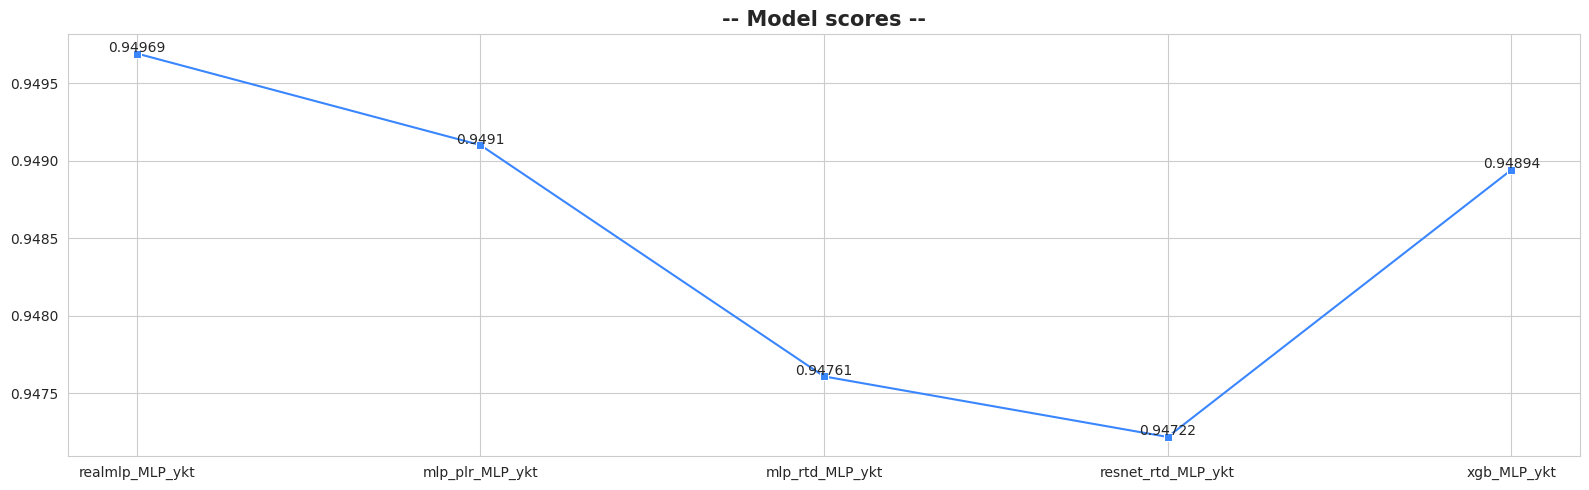

In [23]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, z in v.items():
        if x == 'scores':
            all_scores[k] = z

raw_scores, calib_scores, names = [], [], []

if USE_CALIBRATION:
    for k, g in all_scores.items():
        raw_scores.append(g[0])
        calib_scores.append(g[1])
        names.append(k)
    
    plt.figure(figsize=(16, 5))
    ax1 = sns.lineplot(raw_scores, marker='s', label='base_model')
    ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')
    
    y_add = 4e-4
    
    for i, s1 in enumerate(raw_scores):
        ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')
    
    for i, s2 in enumerate(calib_scores):
        ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')
    
    # plt.legend(loc='best')
    # plt.ylim((0.94, 0.97))
    # plt.xticks(range(len(names)), names, rotation=0)
    # plt.title('Base vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})
    # plt.tight_layout() 
    # plt.show()
else:
    plt.figure(figsize=(16, 5))
    ax1 = sns.lineplot([*all_scores.values()], marker='s')
    
    for i, s in enumerate([*all_scores.values()]):
        ax1.text(float(i), s+1e-5, s, ha='center', va='baseline')
    
# plt.ylim((0.94, 0.97))
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title('-- Model scores --', fontdict={'weight': 'semibold', 'size': 15})
plt.tight_layout()
plt.show()

## Evaluation and Submission

In [24]:
## -- Get OOF predictions --

if USE_CALIBRATION:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, y in v.items():
            if x == "oof_preds":
                n = f"pytab_{k}_calib_{str(calib_scores[i]).split('.')[1]}"
                np.save(f"oof_{n}_.npy", y[1])
                print(f"oof file {n} saved!")
                print()
else:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, y in v.items():
            if x == "oof_preds":
                n = f"pytab_{k}_{str([*all_scores.values()][i]).split('.')[1]}"
                np.save(f"oof_{n}_.npy", y)
                print(f"oof {CFG["YELLOW"]}{n}{CFG["RESET"]} saved!")

oof pytab_realmlp_MLP_ykt_94969 saved!
oof pytab_mlp_plr_MLP_ykt_9491 saved!
oof pytab_mlp_rtd_MLP_ykt_94761 saved!
oof pytab_resnet_rtd_MLP_ykt_94722 saved!
oof pytab_xgb_MLP_ykt_94894 saved!


Submission pytab_realmlp_MLP_ykt_94969 test saved! (295753,)


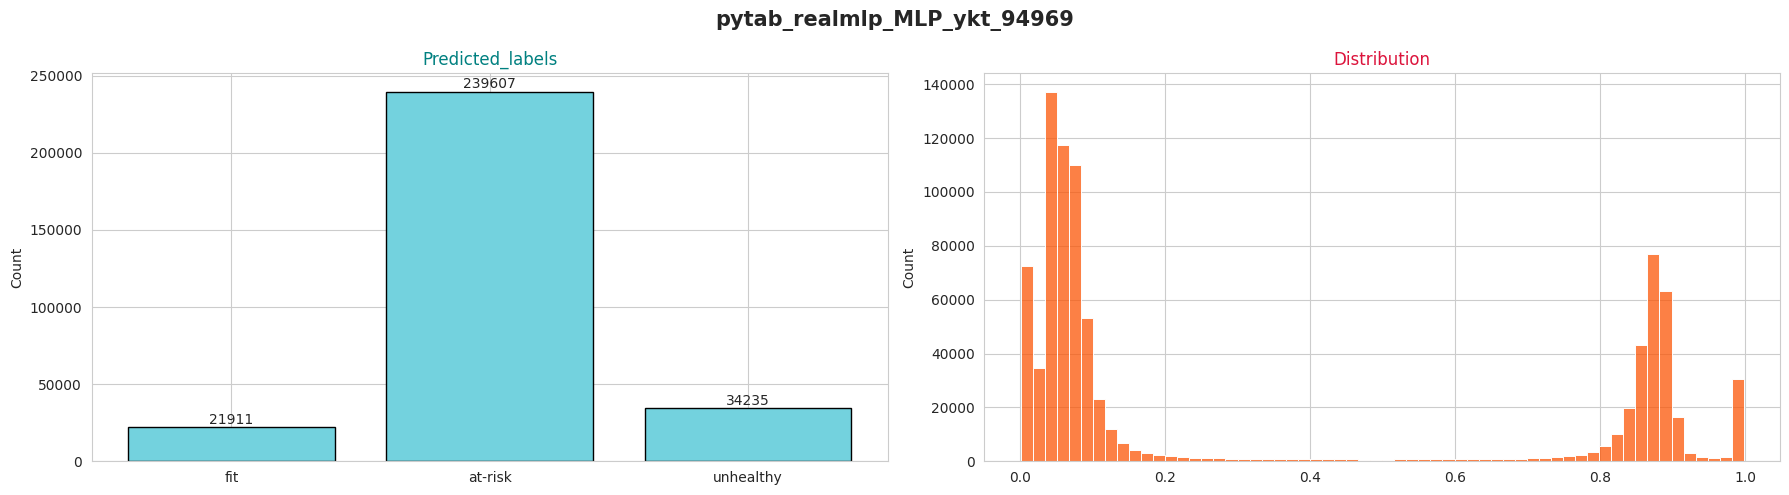

Submission pytab_mlp_plr_MLP_ykt_9491 test saved! (295753,)


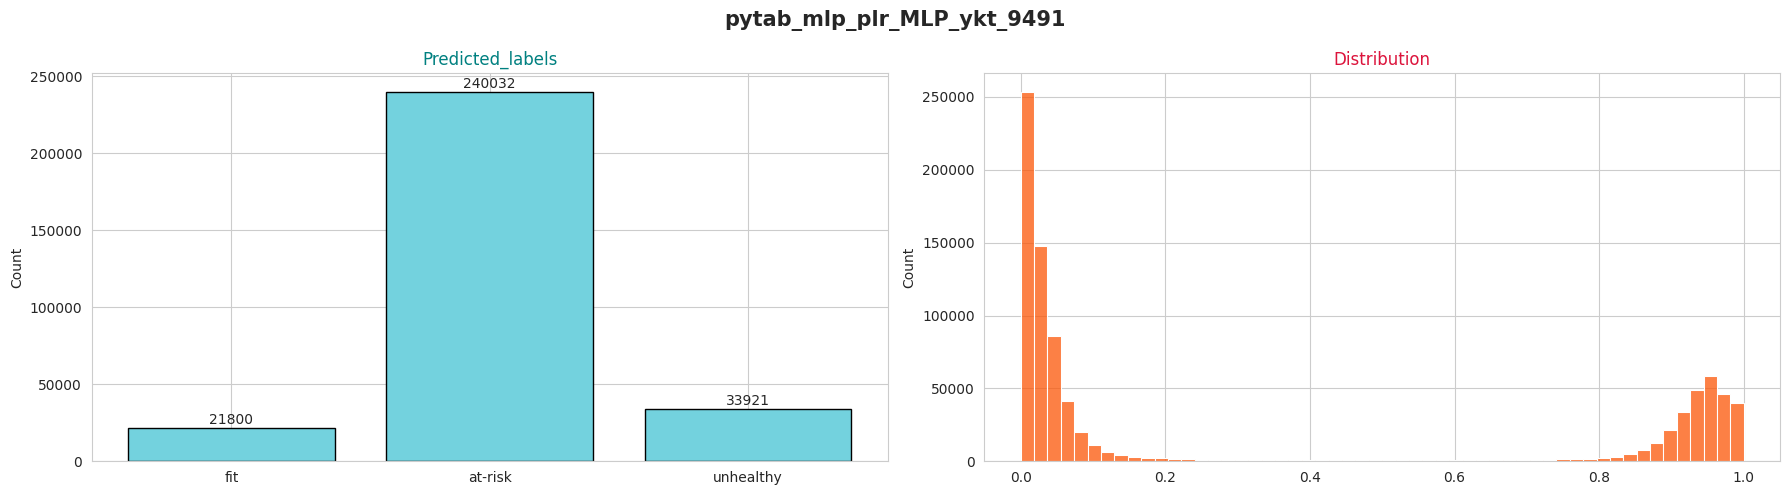

Submission pytab_mlp_rtd_MLP_ykt_94761 test saved! (295753,)


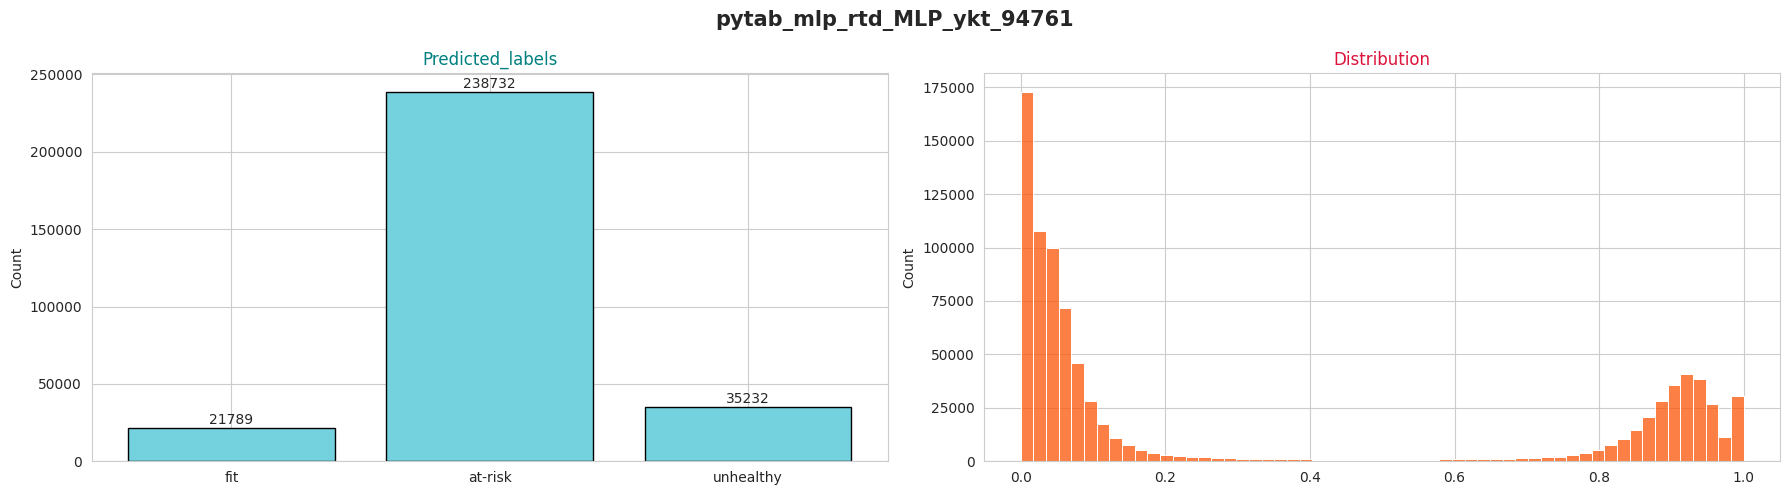

Submission pytab_resnet_rtd_MLP_ykt_94722 test saved! (295753,)


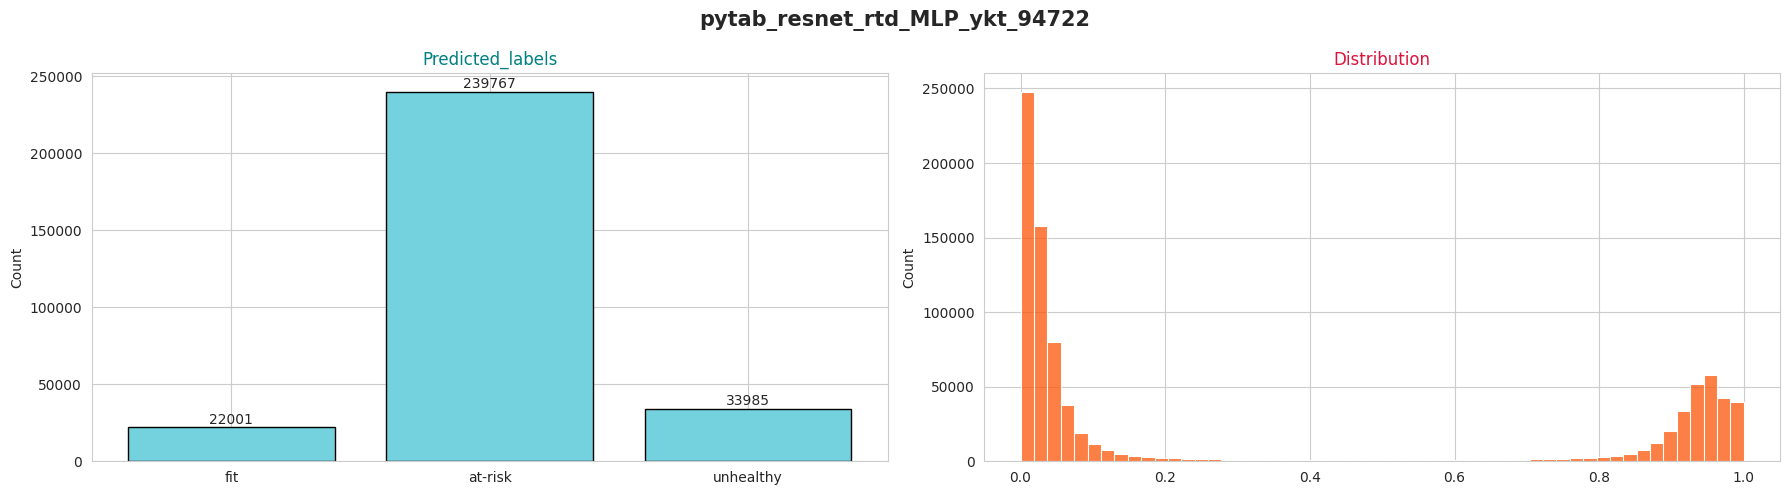

Submission pytab_xgb_MLP_ykt_94894 test saved! (295753,)


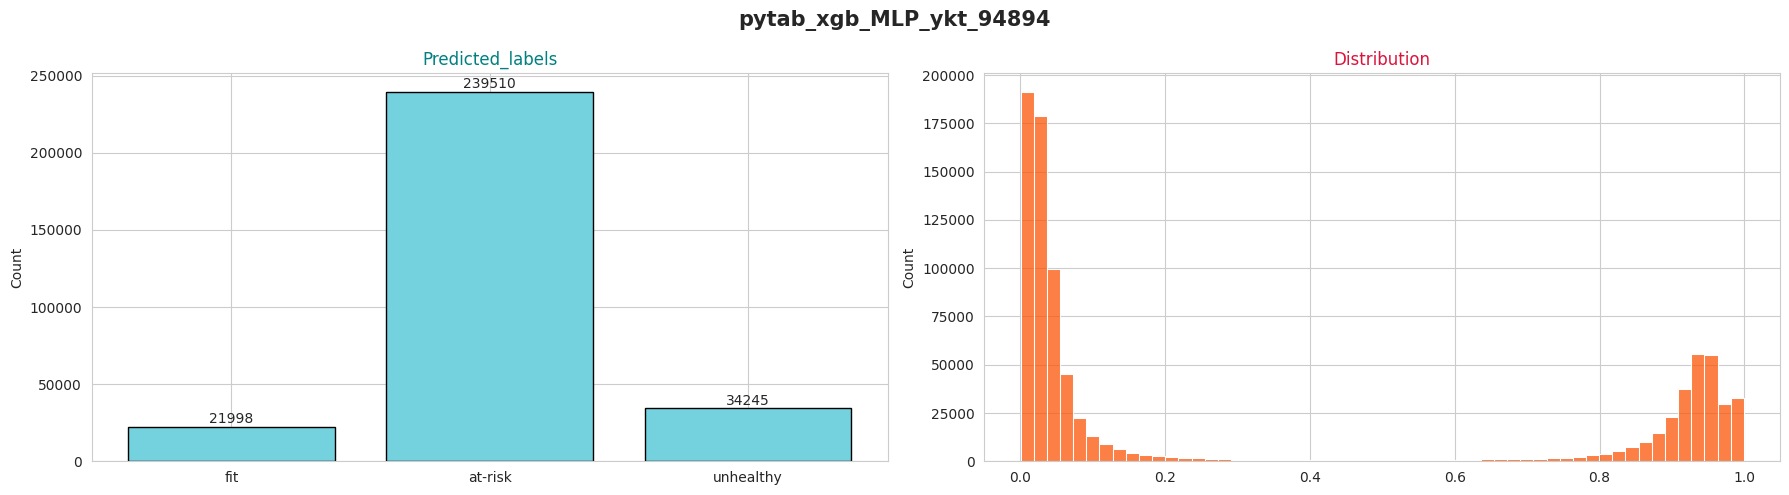

In [25]:
## -- Get TEST predictions --

model_results = {}
class_names = [*mapping.keys()]

if USE_CALIBRATION:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, p in v.items():
            if x == "test_preds":
                ## -- Base submission --
                n = f"pytab_{k}_{str(raw_scores[i]).split('.')[1]}"
                # np.save(f"test_pytab_{n}_.npy", p[0])

                base_preds = np.argmax(p[0], axis=1)
                # submit[TARGET] = pd.Series(base_preds).map(r_mapping)
                # submit.to_csv(f"submit_{n}.csv", index=False)
                # print(f"Submission base {n} test saved! {base_preds.shape}")

                ## -- Calib submission --
                cal_n = f"pytab_{k}_calib_{str(calib_scores[i]).split('.')[1]}"
                np.save(f"test_{cal_n}_.npy", p[1])

                calib_preds = np.argmax(p[1], axis=1)
                submit[TARGET] = pd.Series(calib_preds).map(r_mapping)
                submit.to_csv(f"submit_{cal_n}.csv", index=False)
                print(f"Submission {cal_n} test saved! {calib_preds.shape}")

                model_results[cal_n] = submit[TARGET]
                
                ## -- Distribution plots --
                fig, axes = plt.subplots(1, 2, figsize=(16, 5))
                for i, (ax, preds, title, color) in enumerate([
                    (axes[0], base_preds, f"Base model: {n}", "#73D2DE"),
                    (axes[1], calib_preds, f"Calibrated: {cal_n}", "#FB5607"),
                ]):
                    counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
                    ax.bar(class_names, counts, color=color, edgecolor="k")
                    ax.set_title(title, color=["teal", "crimson"][i])
                    ax.set_ylabel("Count")
                
                    for i, c in enumerate(counts):
                        ax.text(i, c+2000, str(c), ha="center", fontsize=10)
                
                plt.suptitle("Distribution: Base vs Calibrated", fontsize=15, fontweight="semibold")
                plt.tight_layout()
                plt.show()
else:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, p in v.items():
            if x == "test_preds":
                n = f"pytab_{k}_{str([*all_scores.values()][i]).split('.')[1]}"
                np.save(f"test_{n}_.npy", p) 

                base_preds = np.argmax(p, axis=1)
                submit[TARGET] = pd.Series(base_preds).map(r_mapping)
                submit.to_csv(f"submit_{n}.csv", index=False)
                print(f"Submission {n} test saved! {base_preds.shape}")

                model_results[n] = submit[TARGET]

                ## -- Distribution plots --
                counts = [np.sum(base_preds == _) for _ in range(len(np.unique(base_preds)))]

                fig, axs = plt.subplots(1, 2, figsize=(18, 5))
                axs[0].bar(class_names, counts, color="#73D2DE", edgecolor="k")
                axs[0].set_title("Predicted_labels", color="teal")
                axs[0].set_ylabel("Count")
            
                for i, c in enumerate(counts):
                    axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)
            
                sns.histplot(p.ravel(), ax=axs[1], color="#FB5607")
                axs[1].set_title("Distribution", color="crimson")
            
                plt.suptitle(n, fontsize=15, fontweight="semibold")
                plt.tight_layout()
                plt.show()


In [26]:
pd.DataFrame(model_results)

,pytab_realmlp_MLP_ykt_94969,pytab_mlp_plr_MLP_ykt_9491,pytab_mlp_rtd_MLP_ykt_94761,pytab_resnet_rtd_MLP_ykt_94722,pytab_xgb_MLP_ykt_94894
0,unhealthy,unhealthy,unhealthy,unhealthy,unhealthy
1,unhealthy,unhealthy,unhealthy,unhealthy,unhealthy
2,at-risk,at-risk,at-risk,at-risk,at-risk
3,at-risk,at-risk,at-risk,at-risk,at-risk
4,unhealthy,unhealthy,unhealthy,unhealthy,unhealthy
...,...,...,...,...,...
295748,fit,fit,fit,fit,fit
295749,at-risk,at-risk,at-risk,at-risk,at-risk
295750,unhealthy,unhealthy,unhealthy,unhealthy,unhealthy
295751,at-risk,at-risk,at-risk,at-risk,at-risk


In [27]:
# ## -- Distribution plots of the last model --
# if USE_CALIBRATION:
#     class_names = [*mapping.keys()]

#     fig, axes = plt.subplots(1, 2, figsize=(16, 5))
#     for i, (ax, preds, title, color) in enumerate([
#         (axes[0], base_preds, f"Base model: {n}", "#73D2DE"),
#         (axes[1], calib_preds, f"Calibrated: {cal_n}", "#FB5607"),
#     ]):
#         counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
#         ax.bar(class_names, counts, color=color, edgecolor="k")
#         ax.set_title(title, color=["teal", "crimson"][i])
#         ax.set_ylabel("Count")
    
#         for i, c in enumerate(counts):
#             ax.text(i, c+2000, str(c), ha="center", fontsize=10)
    
#     plt.suptitle("Distribution: Base vs Calibrated", fontsize=15, fontweight="semibold")
#     plt.tight_layout()
#     plt.show()
# else:
#     class_names = [*mapping.keys()]
#     counts = [np.sum(base_preds == _) for _ in range(len(np.unique(base_preds)))]

#     fig, axs = plt.subplots(1, 2, figsize=(18, 5))
#     axs[0].bar(class_names, counts, color="#73D2DE", edgecolor="k")
#     axs[0].set_title(f"{n}: Predicted_labels", color="teal")
#     axs[0].set_ylabel("Count")

#     for i, c in enumerate(counts):
#         axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)

#     sns.histplot(p.ravel(), ax=axs[1], color="#FB5607")
#     axs[1].set_title(f"{n}: Distribution", color="crimson")

#     plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
#     plt.tight_layout()
#     plt.show()

In [28]:
# !rm -r /kaggle/working/